In [1]:
# ruff: noqa  # Expect this notebook to be of bad quality
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from misophonia_dataset.interface import get_data_dir
from misophonia_anc._mlflow_stats import (
    auto_combine_mean_with_std,
    RUN_INDEX,
    get_parameters_from_mlflow,
)
import subprocess
import json
from matplotlib.lines import Line2D

/build/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
category_pretty = {
    "chewing": "Chewing",
    "clearing_throat": "Clearing Throat",
    "human_breathing": "Human Breathing",
    "knife_cutting": "Knife Cutting",
    "plastic_crumbling": "Plastic Crumbling",
    "swallowing": "Swallowing",
    "typing": "Typing",
    "water_drops": "Water Drops",
}
source_sound_dist = {
    "chewing": 205,
    "clearing_throat": 337,
    "human_breathing": 352,
    "knife_cutting": 188,
    "plastic_crumbling": 429,
    "swallowing": 108,
    "typing": 434,
    "water_drops": 326,
}
si_sniri_sh_base_e2e = {
    "chewing": 6.88,
    "clearing_throat": 10.0,
    "human_breathing": 7.59,
    "knife_cutting": 11.3,
    "plastic_crumbling": 9.25,
    "swallowing": 10.2,
    "typing": 9.02,
    "water_drops": 7.84,
}
si_sniri_ft = {
    "chewing": (7.88, 8.0),
    "clearing_throat": (10.6, 6.3),
    "human_breathing": (8.09, 6.6),
    "knife_cutting": (11.7, 9.0),
    "plastic_crumbling": (10.0, 7.8),
    "swallowing": (11.0, 1.9),
    "typing": (9.64, 7.1),
    "water_drops": (8.86, 8.4),
}
subtract_data = pd.DataFrame(
    {
        "category": list(sorted(source_sound_dist.keys())),
        "category_pretty": [category_pretty[k] for k in sorted(source_sound_dist.keys())],
        "count": [source_sound_dist[k] for k in sorted(source_sound_dist.keys())],
        "si_sniri_sh_base_e2e": [si_sniri_sh_base_e2e[k] for k in sorted(source_sound_dist.keys())],
        "si_sniri_ft": [si_sniri_ft[k][0] for k in sorted(source_sound_dist.keys())],
        "si_sniri_ft_std": [si_sniri_ft[k][1] for k in sorted(source_sound_dist.keys())],
    }
)
subtract_data

,category,category_pretty,count,si_sniri_sh_base_e2e,si_sniri_ft,si_sniri_ft_std
0,chewing,Chewing,205,6.88,7.88,8.0
1,clearing_throat,Clearing Throat,337,10.00,10.60,6.3
2,human_breathing,Human Breathing,352,7.59,8.09,6.6
3,knife_cutting,Knife Cutting,188,11.30,11.70,9.0
4,plastic_crumbling,Plastic Crumbling,429,9.25,10.00,7.8
5,swallowing,Swallowing,108,10.20,11.00,1.9
6,typing,Typing,434,9.02,9.64,7.1
7,water_drops,Water Drops,326,7.84,8.86,8.4


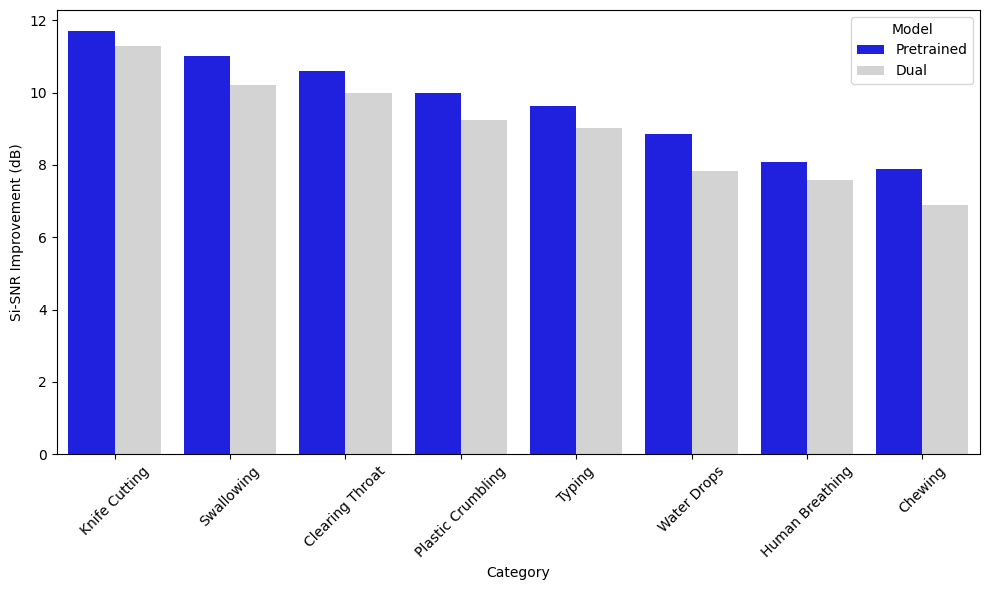

In [4]:
# Bar plot of the Si-SNRi per category between the two models, ordered by best (si_sniri_ft)
order = subtract_data.sort_values("si_sniri_ft", ascending=False)["category_pretty"].tolist()
melted = subtract_data.melt(
    id_vars=["category", "category_pretty", "count"],
    value_vars=["si_sniri_ft", "si_sniri_sh_base_e2e"],
    var_name="model",
    value_name="si_sniri",
)
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=melted,
    x="category_pretty",
    y="si_sniri",
    hue="model",
    palette={"si_sniri_ft": "blue", "si_sniri_sh_base_e2e": "#d3d3d3"},
    order=order,
)

plt.xlabel("Category")
plt.ylabel("Si-SNR Improvement (dB)")

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=["Pretrained", "Dual"], title="Model")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(get_data_dir() / "report_figs" / "si_sniri_per_category.pdf")
plt.show()


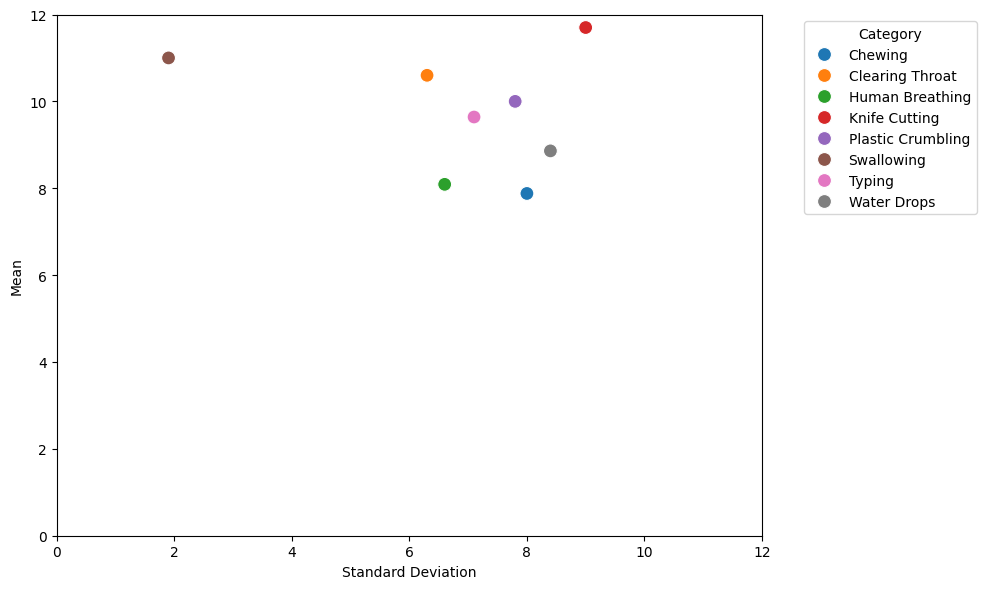

In [5]:
# plot si_sniri_ft vs si_sniri_ft_std
plt.figure(figsize=(10, 6))
ax = sns.scatterplot(
    data=subtract_data,
    x="si_sniri_ft_std",
    y="si_sniri_ft",
    hue="category_pretty",
    palette="tab10",
    s=100,
)
plt.xlabel("Standard Deviation")
plt.ylabel("Mean")
plt.ylim(0, 12)
plt.xlim(0, 12)
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
# plt.savefig(get_data_dir() / "report_figs" / "si_sniri_ft_vs_std.pdf")
plt.show()

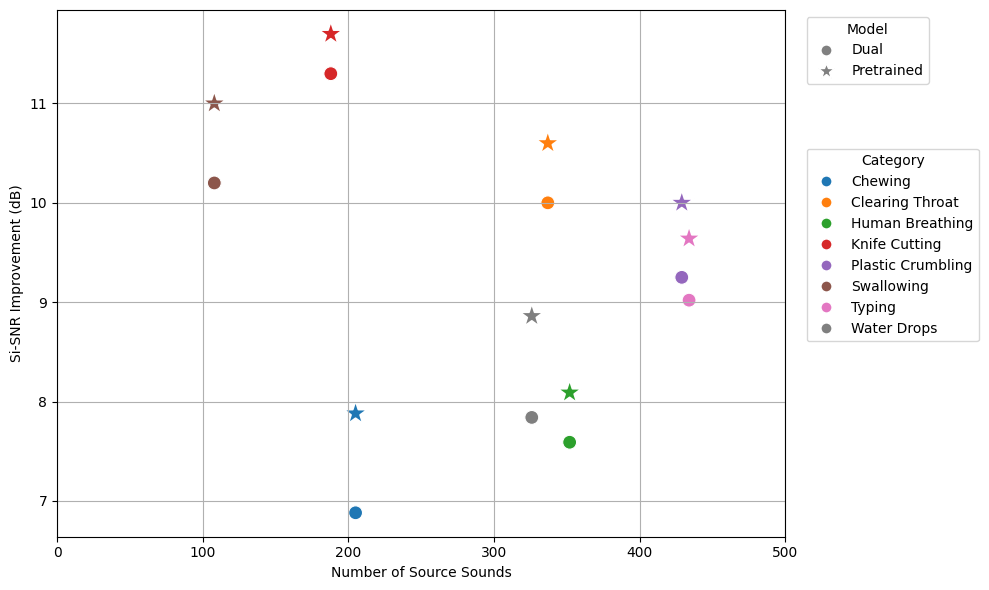

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=subtract_data,
    x="count",
    y="si_sniri_sh_base_e2e",
    hue="category_pretty",
    s=100,
    marker="o",
    legend=False,
    ax=ax,
)

sns.scatterplot(
    data=subtract_data,
    x="count",
    y="si_sniri_ft",
    hue="category_pretty",
    s=350,
    marker="*",
    legend=False,
    ax=ax,
)

ax.set_xlabel("Number of Source Sounds")
ax.set_ylabel("Si-SNR Improvement (dB)")

# Legend 1: model markers
model_proxies = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markersize=8, label="Dual"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="gray", markersize=12, label="Pretrained"),
]
legend1 = ax.legend(
    handles=model_proxies,
    title="Model",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    bbox_transform=ax.transAxes,
    frameon=True,
)

# Legend 2: categories (colors) placed below model legend
colors = sns.color_palette(n_colors=len(subtract_data["category_pretty"]))
cat_proxies = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=tuple(colors[idx]), markersize=8, label=cat)
    for idx, cat in enumerate(subtract_data["category_pretty"])
]
legend2 = ax.legend(
    handles=cat_proxies,
    title="Category",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.75),
    bbox_transform=ax.transAxes,
    frameon=True,
)

ax.add_artist(legend1)

ax.grid()
ax.set_xlim(0, 500)
plt.tight_layout()
plt.savefig(get_data_dir() / "report_figs" / "count_vs_si_sniri.pdf", bbox_inches="tight")
plt.show()


# Extraction

In [7]:
si_sniri_sh_base_extract = {
    "chewing": 2.57,
    "clearing_throat": 4.35,
    "human_breathing": 3.16,
    "knife_cutting": 6.15,
    "plastic_crumbling": 4.93,
    "swallowing": 3.97,
    "typing": 4.17,
    "water_drops": 3.06,
}
si_sniri_sh_ft_extract = {
    "chewing": 3.38,
    "clearing_throat": 4.61,
    "human_breathing": 3.21,
    "knife_cutting": 5.88,
    "plastic_crumbling": 4.97,
    "swallowing": 4.33,
    "typing": 4.42,
    "water_drops": 3.16,
}
si_sniri_sh_ft_le_extract = {
    "chewing": 1.03,
    "clearing_throat": 2.22,
    "human_breathing": 0.764,
    "knife_cutting": 2.88,
    "plastic_crumbling": 2.81,
    "swallowing": 2.87,
    "typing": 2.41,
    "water_drops": 1.67,
}

extract_data = pd.DataFrame(
    {
        "category": list(sorted(source_sound_dist.keys())),
        "category_pretty": [category_pretty[k] for k in sorted(source_sound_dist.keys())],
        "count": [source_sound_dist[k] for k in sorted(source_sound_dist.keys())],
        "si_sniri_sh_base_extract": [si_sniri_sh_base_extract[k] for k in sorted(source_sound_dist.keys())],
        "si_sniri_sh_ft_extract": [si_sniri_sh_ft_extract[k] for k in sorted(source_sound_dist.keys())],
        "si_sniri_sh_ft_le_extract": [si_sniri_sh_ft_le_extract[k] for k in sorted(source_sound_dist.keys())],
    }
)

extract_data["ft_diff"] = extract_data["si_sniri_sh_ft_extract"] - extract_data["si_sniri_sh_ft_le_extract"]

extract_data

,category,category_pretty,count,si_sniri_sh_base_extract,si_sniri_sh_ft_extract,si_sniri_sh_ft_le_extract,ft_diff
0,chewing,Chewing,205,2.57,3.38,1.030,2.350
1,clearing_throat,Clearing Throat,337,4.35,4.61,2.220,2.390
2,human_breathing,Human Breathing,352,3.16,3.21,0.764,2.446
3,knife_cutting,Knife Cutting,188,6.15,5.88,2.880,3.000
4,plastic_crumbling,Plastic Crumbling,429,4.93,4.97,2.810,2.160
5,swallowing,Swallowing,108,3.97,4.33,2.870,1.460
6,typing,Typing,434,4.17,4.42,2.410,2.010
7,water_drops,Water Drops,326,3.06,3.16,1.670,1.490


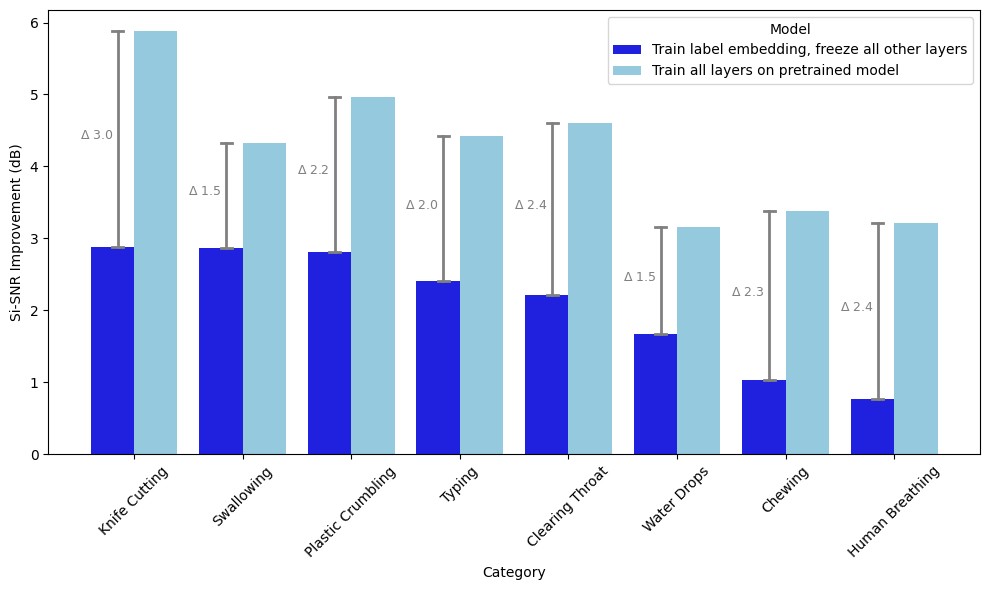

In [8]:
# Plot extract_data as bar plot
order = extract_data.sort_values("si_sniri_sh_ft_le_extract", ascending=False)["category_pretty"].tolist()
melted_extract = extract_data.melt(
    id_vars=["category", "category_pretty", "count"],
    value_vars=[
        "si_sniri_sh_ft_le_extract",
        "si_sniri_sh_ft_extract",
        # "si_sniri_sh_base_extract",
    ],
    var_name="model",
    value_name="si_sniri",
)
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=melted_extract,
    x="category_pretty",
    y="si_sniri",
    hue="model",
    palette={
        "si_sniri_sh_ft_le_extract": "blue",
        "si_sniri_sh_ft_extract": "#87CEEB",
        # "si_sniri_sh_base_extract": "#d3d3d3",
    },
    order=order,
)

# Add vertical line showing the difference between the two models
for i, cat in enumerate(order):
    diff = extract_data[extract_data["category_pretty"] == cat]["ft_diff"].values[0]
    le_val = extract_data[extract_data["category_pretty"] == cat]["si_sniri_sh_ft_le_extract"].values[0]
    ax.plot([i - 0.15, i - 0.15], [le_val, le_val + diff], color="grey", linewidth=2)
    # Add small horizontal caps at both ends
    ax.plot([i - 0.2, i - 0.1], [le_val, le_val], color="grey", linewidth=2)
    ax.plot([i - 0.2, i - 0.1], [le_val + diff, le_val + diff], color="grey", linewidth=2)
    # Add text showing the difference
    ax.text(i - 0.5, le_val + diff / 2, f"$\Delta~{diff:.1f}$", fontsize=9, va="baseline", color="grey")

plt.xlabel("Category")
plt.ylabel("Si-SNR Improvement (dB)")
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=[
        "Train label embedding, freeze all other layers",
        "Train all layers on pretrained model",
        # "Dual",
    ],
    title="Model",
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(get_data_dir() / "report_figs" / "si_sniri_per_category_extract_le.pdf")
plt.show()

In [9]:
# fig, ax = plt.subplots(figsize=(10, 6))

# sns.scatterplot(
#     data=extract_data,
#     x="count",
#     y="si_sniri_sh_base_extract",
#     hue="category_pretty",
#     s=100,
#     marker="o",
#     legend=False,
#     ax=ax,
# )

# sns.scatterplot(
#     data=extract_data,
#     x="count",
#     y="si_sniri_sh_ft_extract",
#     hue="category_pretty",
#     s=350,
#     marker="*",
#     legend=False,
#     ax=ax,
# )

# sns.scatterplot(
#     data=extract_data,
#     x="count",
#     y="si_sniri_sh_ft_le_extract",
#     hue="category_pretty",
#     s=200,
#     marker="p",
#     legend=False,
#     ax=ax,
# )

# ax.set_xlabel("Number of Source Sounds")
# ax.set_ylabel("Si-SNR Improvement (dB)")

# # Legend 1: model markers
# model_proxies = [
#     Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markersize=8, label="Dual"),
#     Line2D([0], [0], marker="*", color="w", markerfacecolor="gray", markersize=12, label="Pretrained"),
#     Line2D([0], [0], marker="p", color="w", markerfacecolor="gray", markersize=12, label="Label embedding \nadapted"),
# ]
# legend1 = ax.legend(
#     handles=model_proxies,
#     title="Model",
#     loc="upper left",
#     bbox_to_anchor=(1.02, 1.0),
#     bbox_transform=ax.transAxes,
#     frameon=True,
# )

# # Legend 2: categories (colors) placed below model legend
# colors = sns.color_palette(n_colors=len(extract_data["category_pretty"]))
# cat_proxies = [
#     Line2D([0], [0], marker="o", color="w", markerfacecolor=tuple(colors[idx]), markersize=8, label=cat)
#     for idx, cat in enumerate(extract_data["category_pretty"])
# ]
# legend2 = ax.legend(
#     handles=cat_proxies,
#     title="Category",
#     loc="upper left",
#     bbox_to_anchor=(1.02, 0.75),
#     bbox_transform=ax.transAxes,
#     frameon=True,
# )

# ax.add_artist(legend1)

# ax.grid()
# ax.set_xlim(0, 500)
# plt.tight_layout()
# # plt.savefig(get_data_dir() / "report_figs" / "extract_count_vs_si_sniri.pdf", bbox_inches='tight')
# plt.show()
